In [1]:
import numpy as np
import pandas as pd
import urllib
import json
from pathlib import Path
%matplotlib inline

/cvmfs/cdms.opensciencegrid.org/releases/centos7/V04-06/lib/python3.7/site-packages/pandas/compat/_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.9' currently installed).
  warnings.warn(msg, UserWarning)


## Import metadata from Google Sheets

* [Access Google Sheet](https://docs.google.com/spreadsheets/d/1YklUMHrcqeEHhJtmiXgvCnb2B_SaIt99sZ-T6u1Kszc/edit#gid=0)

In [2]:
sheet_id = "1YklUMHrcqeEHhJtmiXgvCnb2B_SaIt99sZ-T6u1Kszc"
sheet_name = urllib.parse.quote("Raw data v2")
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

df = pd.read_csv(url)

In [3]:
# remove empty columns

df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

In [4]:
df["nDataType"]

0      noSource
1      noSource
2      noSource
3      noSource
4      noSource
         ...   
122    noSource
123    noSource
124    noSource
125    noSource
126    noSource
Name: nDataType, Length: 127, dtype: object

In [5]:
df.columns

Index(['Facility', 'nFridgeRun', 'DCRCversion', 'DCRCFirmwareVersion',
       'Series', 'nDataType', 'SourcePos_Cs', 'SourcePos_Ba', 'Category',
       'Filetype', 'AnalysisTag', 'HV', 'Shield', 'WorkingPoint',
       'MCTemperature', 'Path'],
      dtype='object')

In [6]:
!head NEXUS_R13_unblinded_raw_files.txt

/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw/25220405_152020/25220405_152020_F0001.mid.gz
/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw/25220405_154619/25220405_154619_F0001.mid.gz
/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw/25220405_155041/25220405_155041_F0001.mid.gz
/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw/25220406_094740/25220406_094740_F0001.mid.gz
/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw/25220406_094227/25220406_094227_F0001.mid.gz
/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw/25220406_094148/25220406_094148_F0001.mid.gz
/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw/25220406_094109/25220406_094109_F0001.mid.gz
/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw/25220405_155351/25220405_155351_F0001.mid.gz
/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw/25220405_151740/25220405_151740_F0001.mid.gz
/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw/25220329_143754/25220329_143754_F1190.mid.gz


## Data and functions used for conversion

In [7]:
facilities = {25: "NEXUS"}

In [8]:
## From previous analysis
n_data_types = {
    "Test": -1,
    "Background": 0,
    "Co": 1,
    "Co LowR": 2,
    "Cf": 3,
    "Rand": 4,
    "Mon": 7,
    "Cs source": 8,
    "Ba": 9,
    "YBe": 12,
    "SbBe": 13,
    "Y Blank": 14,
    "Sb Blank": 15,
    "Laser": 16,
    "Beam": 17,
    "Beam + Laser": 18,
    "Fe55 source": 19,
    "Fe55": 19,
    "Co57": 20,
    "IV curve": 100,
    "dIdV": 101,
    "NM noise": 102,
    "SC noise": 103,
    "TS noise": 104,
}

## New for Nexus 13

n_data_types["Cs-137"] = 8 # same as "Cs source"
n_data_types["noSource"] = 0 # like "Low Background"

In [9]:
def extract_nDump(filename):
    return int(filename.split("/")[-1].split("F")[1].split(".")[0])

In [10]:
assert extract_nDump('/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw/25220319_095807/25220319_095807_F1200.mid.gz') == 1200

## Only register unblinded data

In [11]:
len(df)

127

In [12]:
df = df[df["Path"].str.contains("unblinded")]

In [13]:
len(df)

17

## List file in series

In [14]:
file_list = pd.read_table("NEXUS_R13_unblinded_raw_files.txt", squeeze=False, header=None, names=["file_path"])

In [15]:
file_list[["path", "series", "file_name"]] = file_list["file_path"].str.rsplit("/", n=2, expand=True)

In [16]:
file_list.head()

,file_path,path,series,file_name
0,/sdf/group/supercdms/data/CDMS/NEXUS/R13_unbli...,/sdf/group/supercdms/data/CDMS/NEXUS/R13_unbli...,25220405_152020,25220405_152020_F0001.mid.gz
1,/sdf/group/supercdms/data/CDMS/NEXUS/R13_unbli...,/sdf/group/supercdms/data/CDMS/NEXUS/R13_unbli...,25220405_154619,25220405_154619_F0001.mid.gz
2,/sdf/group/supercdms/data/CDMS/NEXUS/R13_unbli...,/sdf/group/supercdms/data/CDMS/NEXUS/R13_unbli...,25220405_155041,25220405_155041_F0001.mid.gz
3,/sdf/group/supercdms/data/CDMS/NEXUS/R13_unbli...,/sdf/group/supercdms/data/CDMS/NEXUS/R13_unbli...,25220406_094740,25220406_094740_F0001.mid.gz
4,/sdf/group/supercdms/data/CDMS/NEXUS/R13_unbli...,/sdf/group/supercdms/data/CDMS/NEXUS/R13_unbli...,25220406_094227,25220406_094227_F0001.mid.gz


In [17]:
len(file_list)

7249

In [18]:
file_list_grouped = file_list.groupby(["path", "series"])

### Statistics about the series

Number of files per series

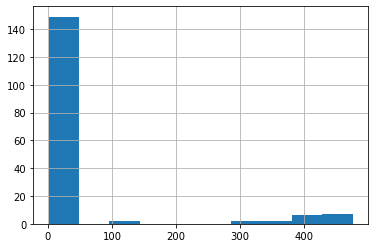

In [19]:
file_list_grouped["file_name"].count().hist();

In [20]:
file_list_grouped["file_name"].count().describe()

count    168.000000
mean      43.148810
std      123.548029
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max      476.000000
Name: file_name, dtype: float64

In [21]:
def list_file(path, series):
    """List files at path
    
    This works without actual access to the filesystem, reads from pregenerated text file"""
    return file_list_grouped.get_group((path, series))["file_path"].to_list()

In [22]:
assert len(list_file("/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw", "25220329_143754")) == 394

## Iterate by row and register the data

* Iterate through all rows in the Pandas Dataframe
* Build a dictionary of processed metadata
* Call `ContinuousRawData` with the `record` dictionary as arguments

In [23]:
records = []
for row in df.to_dict(orient="records"):
    record = dict(
        filePath=row.pop("Path"),
        facility=facilities[row.pop("Facility")],
        nFridgeRun=row.pop("nFridgeRun"),
        nDataType=n_data_types.get(row.pop("nDataType"), np.nan),
        Series=row.pop("Series"),
        nIsJunk=0,
    )
    record["commentStart"] = [json.dumps(row)]
    for file in list_file(record["filePath"], record["Series"]):
        record["fileName"] = file
        record["nDumpNum"] = extract_nDump(file)
        records.append(record.copy())

In [24]:
len(records)

6708

In [25]:
records[0]

{'filePath': '/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw',
 'facility': 'NEXUS',
 'nFridgeRun': 13,
 'nDataType': 0,
 'Series': '25220319_095807',
 'nIsJunk': 0,
 'commentStart': ['{"DCRCversion": "RevE_SN19", "DCRCFirmwareVersion": "a58c184", "SourcePos_Cs": NaN, "SourcePos_Ba": NaN, "Category": "Raw", "Filetype": ".mid.gz", "AnalysisTag": "HVeV_R4_science", "HV": 100, "Shield": "close", "WorkingPoint": "46/46/40/40/18/14/52/51", "MCTemperature": 11.0}'],
 'fileName': '/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw/25220319_095807/25220319_095807_F1200.mid.gz',
 'nDumpNum': 1200}

In [26]:
records[1]

{'filePath': '/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw',
 'facility': 'NEXUS',
 'nFridgeRun': 13,
 'nDataType': 0,
 'Series': '25220319_095807',
 'nIsJunk': 0,
 'commentStart': ['{"DCRCversion": "RevE_SN19", "DCRCFirmwareVersion": "a58c184", "SourcePos_Cs": NaN, "SourcePos_Ba": NaN, "Category": "Raw", "Filetype": ".mid.gz", "AnalysisTag": "HVeV_R4_science", "HV": 100, "Shield": "close", "WorkingPoint": "46/46/40/40/18/14/52/51", "MCTemperature": 11.0}'],
 'fileName': '/sdf/group/supercdms/data/CDMS/NEXUS/R13_unblinded/Raw/25220319_095807/25220319_095807_F0512.mid.gz',
 'nDumpNum': 512}

In [27]:
records_df =pd.DataFrame(records)

records_df.to_csv("Nexus_13_registration_unblinded.csv")

In [28]:
records_df.groupby("Series")["filePath"].count()

Series
25220319_095807    422
25220320_092617    432
25220321_092812    104
25220321_152700    430
25220322_151939    468
25220323_172025    377
25220324_155844    389
25220325_133406    413
25220326_123100    476
25220327_150006    433
25220328_152554    419
25220329_143754    394
25220330_151133    398
25220331_143050    347
25220401_104524    461
25220402_122040    440
25220403_125822    305
Name: filePath, dtype: int64

The CSV is saved into https://docs.google.com/spreadsheets/d/16s31Vvu72A12LDkZBd7IkDK1B3GbMGK0d8ymli7RSY4/edit#gid=962568114